# Prediction of the target in the Test.csv

## Preprocessing of the Test.csv

In [32]:
import pandas as pd
import numpy as np
import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import preprocess_for_air_quality

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_squared_error

RSEED = 42

In [33]:
#df_test = pd.read_csv('data/Test.csv')

In [34]:
import pickle

model_path = "models/model_randomforest.pkl"   # relativer Pfad
with open(model_path, "rb") as file:
    loaded_model = pickle.load(file)

print("✅ Modell erfolgreich geladen!")

✅ Modell erfolgreich geladen!


In [35]:
df = pd.read_csv('data/Train.csv')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

In [37]:
df.isna().sum()

Place_ID X Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    24765
L3_CH4_sensor_azimuth_angle     24765
L3_CH4_sensor_zenith_angle      24765
L3_CH4_solar_azimuth_angle      24765
L3_CH4_solar_zenith_angle       24765
Length: 82, dtype: int64

In [38]:
df_train, df_test = train_test_split(df, random_state=RSEED, train_size=0.2)

In [39]:
df_train_proc = preprocess_for_air_quality(df_train)

In [40]:
df_test_proc = preprocess_for_air_quality(df_test)

In [69]:
df_train_proc.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_AER_AI_absorbing_aerosol_index,L3_SO2_SO2_column_number_density
0,010Q650 X 2020-01-11,2020-01-11,010Q650,24.0,16.0,32.0,279.19,85,-0.445819,-1.849847,...,-0.848251,-0.404114,-0.308917,-0.272424,-0.774326,0.446147,-0.890848,-1.053949,1.606420,0.876826
1,010Q650 X 2020-01-13,2020-01-13,010Q650,25.0,17.0,41.0,286.02,90,-0.131284,-2.053901,...,-0.897930,-0.640720,0.175733,-0.014990,-0.479171,0.037969,-1.079451,-0.852106,2.626510,-1.041693
2,010Q650 X 2020-01-15,2020-01-15,010Q650,23.0,11.0,43.0,682.80,96,0.271230,-1.677186,...,-1.251464,-0.591328,0.482903,-0.298045,-0.739658,-1.008759,-0.683996,-0.563670,2.447116,0.191365
3,010Q650 X 2020-01-18,2020-01-18,010Q650,60.0,39.0,96.0,2762.28,81,-0.101832,-1.855079,...,-0.594384,-0.633978,0.155774,0.570448,2.283263,1.084698,-0.834769,-1.215254,-0.372440,0.338891
4,010Q650 X 2020-01-26,2020-01-26,010Q650,27.0,9.0,51.0,1525.35,81,0.452961,-2.053901,...,-1.179850,-0.667844,-1.248459,0.970878,0.078065,-0.778870,-0.801266,-0.584835,0.990932,-0.025472


In [42]:
df_test_proc.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_AER_AI_absorbing_aerosol_index,L3_SO2_SO2_column_number_density
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,-0.417403,-0.514728,...,-0.812065,-0.635125,-1.428228,-0.120044,-0.238446,-1.018600,-1.198676,-0.623404,-0.096965,-0.606914
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,-0.078378,-1.122321,...,-0.647686,-0.761932,-1.340920,0.202342,1.046299,-1.066551,-1.027345,-0.631172,0.198598,0.160744
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,0.091135,-1.943103,...,-1.207651,-0.739359,-1.465850,0.154238,0.481453,-1.019669,-0.961280,-0.687913,0.360133,0.160252
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,-0.802390,-2.588004,...,-0.587854,0.092243,-1.416401,0.096259,-0.036079,-0.969578,-0.847819,-0.554919,0.805567,0.343967
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,-0.144299,-1.340841,...,-1.152549,-0.399595,0.127431,0.075236,0.677215,0.857118,-1.091857,-1.234817,2.817109,0.694351


In [43]:
df_test_proc.isna().sum()

Place_ID X Date                                    0
Date                                               0
Place_ID                                           0
target                                             0
target_min                                         0
target_max                                         0
target_variance                                    0
target_count                                       0
precipitable_water_entire_atmosphere               0
relative_humidity_2m_above_ground                  0
specific_humidity_2m_above_ground                  0
temperature_2m_above_ground                        0
u_component_of_wind_10m_above_ground               0
v_component_of_wind_10m_above_ground               0
L3_NO2_NO2_column_number_density                   0
L3_NO2_tropospheric_NO2_column_number_density      0
L3_O3_O3_column_number_density                     0
L3_CO_CO_column_number_density                     0
L3_CO_H2O_column_number_density               

In [44]:
df_test_proc.isna().sum()

Place_ID X Date                                    0
Date                                               0
Place_ID                                           0
target                                             0
target_min                                         0
target_max                                         0
target_variance                                    0
target_count                                       0
precipitable_water_entire_atmosphere               0
relative_humidity_2m_above_ground                  0
specific_humidity_2m_above_ground                  0
temperature_2m_above_ground                        0
u_component_of_wind_10m_above_ground               0
v_component_of_wind_10m_above_ground               0
L3_NO2_NO2_column_number_density                   0
L3_NO2_tropospheric_NO2_column_number_density      0
L3_O3_O3_column_number_density                     0
L3_CO_CO_column_number_density                     0
L3_CO_H2O_column_number_density               

In [45]:
df_test_proc.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_AER_AI_absorbing_aerosol_index,L3_SO2_SO2_column_number_density
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,-0.417403,-0.514728,...,-0.812065,-0.635125,-1.428228,-0.120044,-0.238446,-1.018600,-1.198676,-0.623404,-0.096965,-0.606914
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,-0.078378,-1.122321,...,-0.647686,-0.761932,-1.340920,0.202342,1.046299,-1.066551,-1.027345,-0.631172,0.198598,0.160744
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,0.091135,-1.943103,...,-1.207651,-0.739359,-1.465850,0.154238,0.481453,-1.019669,-0.961280,-0.687913,0.360133,0.160252
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,-0.802390,-2.588004,...,-0.587854,0.092243,-1.416401,0.096259,-0.036079,-0.969578,-0.847819,-0.554919,0.805567,0.343967
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,-0.144299,-1.340841,...,-1.152549,-0.399595,0.127431,0.075236,0.677215,0.857118,-1.091857,-1.234817,2.817109,0.694351


In [46]:
X_train = df_train_proc.drop(columns=['Place_ID X Date', 'Date', 'Place_ID', 'target','target_min', 'target_max', 'target_variance', 'target_count'])
y_train = df_train_proc['target'] 

In [47]:
X_test = df_test_proc.drop(columns=['Place_ID X Date', 'Date', 'Place_ID', 'target','target_min', 'target_max', 'target_variance', 'target_count'])
y_test = df_test_proc['target'] 

In [48]:
def print_pretty_summary(name, y_actual, y_pred):
    print(name)
    print('=======================')
    
    r2 = r2_score(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    print(f"R²:   {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print()

In [71]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import fbeta_score, make_scorer

# --- CV und Scorer definieren ---
tscv = TimeSeriesSplit(n_splits=5)
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

# --- Modell ---
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# --- Parameter-Raum ---
param_dist = {
    "n_estimators": [200, 500],
    "max_depth": [None, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.8],
    "bootstrap": [True],
}

# --- Randomized Search ---
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,                  # Anzahl zufälliger Kombinationen
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

rand_search.fit(X_train, y_train)

# --- Ergebnisse ---
print("\nBeste Parameterkombination:")
print(rand_search.best_params_)
print("Bester RMSE (CV):", -rand_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Beste Parameterkombination:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Bester RMSE (CV): 37.902425616326184


beste parameter for RandomForestReg:  
{'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 16, 'bootstrap': True}

In [52]:
rf = RandomForestRegressor(n_estimators= 400, min_samples_split= 2, min_samples_leaf= 1, max_features= 'sqrt', max_depth= None, bootstrap= True, random_state=RSEED)
rf.fit(X_train, y_train)



RandomForestRegressor(max_features='sqrt', n_estimators=400, random_state=42)

In [ ]:
y_pred_test = rf.predict(X_test)

In [73]:
rf_hyper = rand_search.best_estimator_
y_pred_hyper = rf_hyper.predict(X_train)
print_pretty_summary('RF randomizedSearchCV - TRAIN', y_train, y_pred_hyper)

y_pred_test_hyper = rf_hyper.predict(X_test)
print_pretty_summary('RF randomizedSearchCV - TEST', y_test, y_pred_test_hyper)

RF randomizedSearchCV - TRAIN
R²:   0.862
RMSE: 17.958

RF randomizedSearchCV - TEST
R²:   0.477
RMSE: 33.676



In [54]:
y_pred = rf.predict(X_train)

In [55]:
#y_pred_loaded = loaded_model.predict(X_test)
#print_pretty_summary('loaded model', y_test, y_pred_loaded)

In [74]:
print_pretty_summary('RF TRAIN (Parameter Mel)', y_train, y_pred)
print_pretty_summary('RF TEST (Parameter Mel)', y_test, y_pred_test)

RF TRAIN (Parameter Mel)
R²:   0.928
RMSE: 12.944

RF TEST (Parameter Mel)
R²:   0.474
RMSE: 33.769



In [59]:
#y_pred_final = rf.predict(X_final)

In [60]:
#rf_best_rs.fit(X_train, y_train)
#fi = (pd.DataFrame({
#        "feature": X_train.columns,
#        "importance": rf_best_rs.featureimportances
#     })
#     .sort_values("importance", ascending=False))
#print(fi.head(20))

In [61]:
df_y_pred_test = pd.DataFrame(y_pred_test)

df_y_pred_test.head()
#df_y_pred_test.info()

,0
0,39.75750
1,51.72925
2,40.51500
3,52.13000
4,69.12000


In [62]:
y_pred_series = df_y_pred_test.iloc[:, 0].reset_index(drop=True)
y_pred_series.name = 'y_pred'
df_pred_concat = pd.concat(
    [
        df_test_proc.Date.reset_index(drop=True),
        df_test_proc.Place_ID.reset_index(drop=True),
        y_pred_series
    ],
    axis=1
)

df_pred_concat.columns = ['Date', 'Place_ID', 'y_pred']

In [63]:
df_pred_concat.tail(50)
#df_pred_concat.info()

,Date,Place_ID,y_pred
22746,2020-01-13,YWSFY6Q,77.01500
22747,2020-01-14,YWSFY6Q,56.89000
22748,2020-01-16,YWSFY6Q,88.50750
22749,2020-01-17,YWSFY6Q,84.11000
22750,2020-01-18,YWSFY6Q,73.67000
22751,2020-01-21,YWSFY6Q,68.46000
22752,2020-01-22,YWSFY6Q,70.53000
22753,2020-01-23,YWSFY6Q,65.42500
22754,2020-01-24,YWSFY6Q,90.46500
22755,2020-01-25,YWSFY6Q,83.37250


In [64]:
df_pred_concat.groupby(by='Place_ID').value_counts()

Place_ID  Date        y_pred  
010Q650   2020-01-02  39.75750    1
          2020-01-03  51.72925    1
          2020-03-17  48.88500    1
          2020-03-16  55.71250    1
          2020-03-15  61.93000    1
                                 ..
YWSFY6Q   2020-01-11  88.66000    1
          2020-01-09  66.44500    1
          2020-01-08  67.29250    1
          2020-01-02  47.82750    1
          2020-03-19  60.33750    1
Name: count, Length: 22796, dtype: int64

In [65]:
df_pred_concat.Date.nunique()

94

In [66]:
print(df_test_proc.Date.nunique())
print(df_test.Date.nunique())

94
94


In [67]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_actual_vs_pred_over_time(
    model, X, y, meta_df,
    date_col="Date", place_col="Place_ID",
    place_id=None, rolling=None, title_prefix="PM2.5"
):
    """
    Plot Actual vs. Predicted PM2.5 über die Zeit.
    
model: trainiertes Modell oder Pipeline mit .predict()
X, y: Trainings-Features/-Ziel (y als Series, index wie X)
meta_df: DataFrame mit Date & Place_ID für dieselben Zeilen (Index == X.index)
place_id: optional, nur diesen Ort plotten (z.B. '010G650')
rolling: optionales Fenster (z.B. 3) für gleitenden Mittelwert
"""

    # Vorhersagen
    y_pred = model.predict(X)

    # Zusammenführen und sortieren
    dfp = pd.DataFrame({
        "Date": meta_df.Date,
        "Place_ID": meta_df[place_col],
        "Actual": y.values if isinstance(y, pd.Series) else y,
        "Pred": y_pred
    }, index=meta_df.index)

    if place_id is not None:
        dfp = dfp[dfp["Place_ID"] == place_id]

    dfp = dfp.sort_values("Date")

    # optional glätten
    if rolling is not None and rolling > 1:
        dfp["Actual_plot"] = dfp["Actual"].rolling(rolling, min_periods=1).mean()
        dfp["Pred_plot"]   = dfp["Pred"].rolling(rolling, min_periods=1).mean()
    else:
        dfp["Actual_plot"], dfp["Pred_plot"] = dfp["Actual"], dfp["Pred"]

    # Plot
    plt.figure(figsize=(12,4))
    plt.plot(dfp["Date"], dfp["Actual_plot"], label="Actual PM2.5")
    plt.plot(dfp["Date"], dfp["Pred_plot"],   label="Predicted PM2.5")
    ttl = f"{title_prefix} Trend"
    if place_id is not None:
        ttl += f" — {place_id}"
    plt.title(ttl)
    plt.xlabel("Date")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

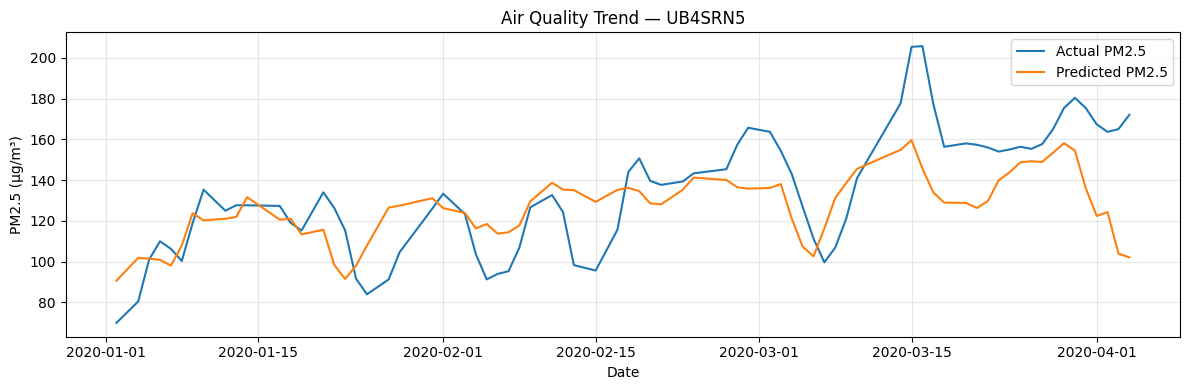

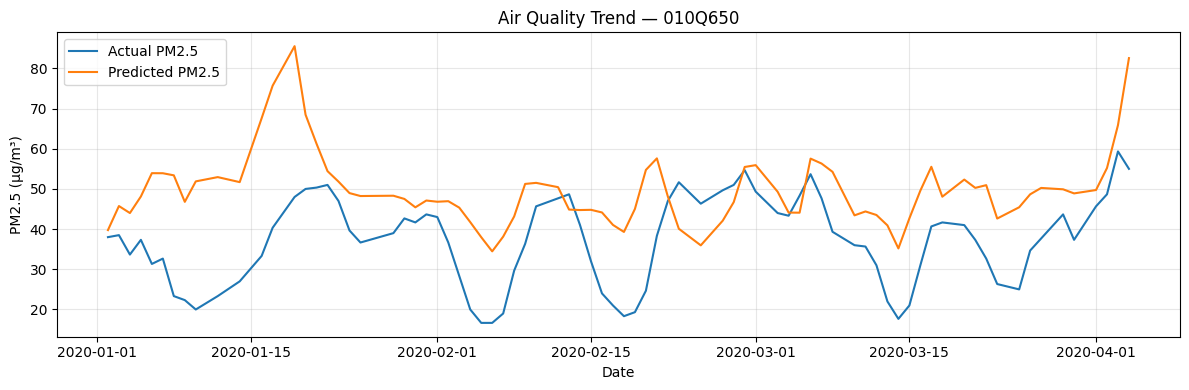

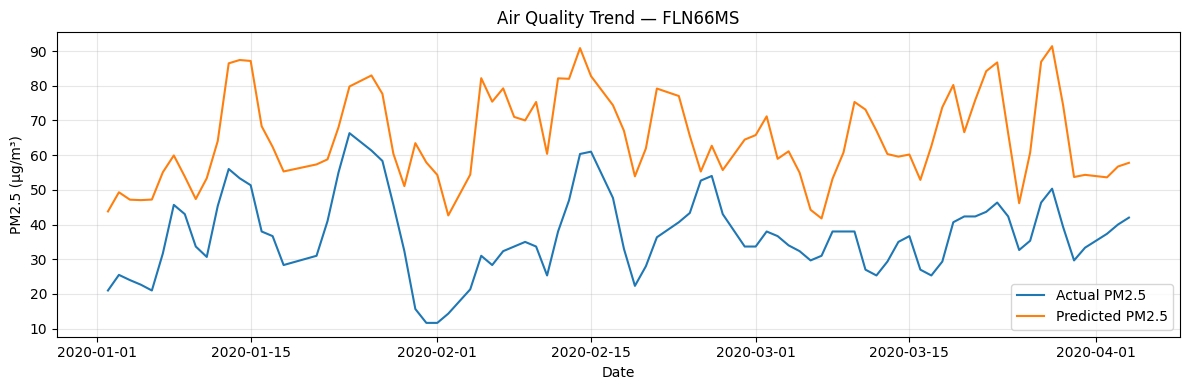

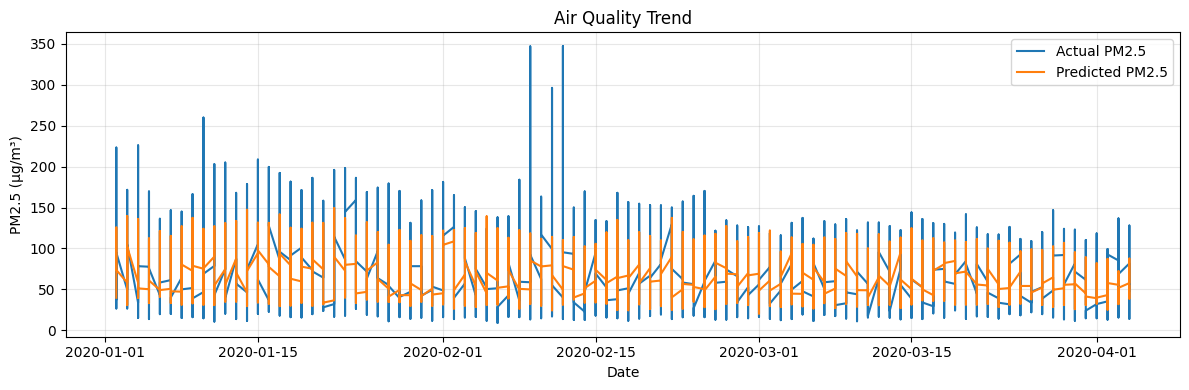

In [68]:
# meta_df muss zu X/y passen und die Originalspalten Date & Place_ID enthalten
#meta_train = df.loc[df_pred_concat.index, ["Date", "Place_ID"]]

# 1) Plot für einen Ort (wie im Beispielbild)
plot_actual_vs_pred_over_time(rf, X_test, y_test, df_pred_concat,
                              place_id="UB4SRN5", rolling=3, title_prefix="Air Quality")

# 1) Plot für einen Ort (wie im Beispielbild)
plot_actual_vs_pred_over_time(rf, X_test, y_test, df_pred_concat,
                              place_id="010Q650", rolling=3, title_prefix="Air Quality")

# 1) Plot für einen Ort (wie im Beispielbild)
plot_actual_vs_pred_over_time(rf, X_test, y_test, df_pred_concat,
                              place_id="FLN66MS", rolling=3, title_prefix="Air Quality")

# 2) Gesamter Trainingssatz (alle Orte zusammen)
plot_actual_vs_pred_over_time(rf, X_test, y_test, df_pred_concat,
                              place_id=None, rolling=3, title_prefix="Air Quality")